# Quantum RNG oparty na fluktuacjach prozni (vacuum-fluctuation QRNG)

## Punkt wyjscia projektu (P7)

> Vacuum-fluctuation QRNGs are arguably the easiest way to do a serious physics-heavy project without building custom hardware yourself. Australian National University publicly states that its service supplies real-time random numbers generated by measuring quantum vacuum fluctuations, and it documents an API that returns data in JSON. On the research side, vacuum-fluctuation QRNGs span balanced-homodyne designs around hundreds of Mbit/s and integrated devices at 100 Gbit/s, so there is both an accessible public data source and a deep modern literature behind it.

P7 wykorzystuje to zalozenie bezposrednio: budujemy walidowalny generator, ktory pobiera probki z publicznego API ANU i mapuje je do interfejsu projektowego (`random_uint64`, `random_floats`, `random_bits`, `random_bytes`).

## Dlaczego ten kierunek jest dobry do projektu

1. **Silna podstawa fizyczna:** zrodlo losowosci pochodzi z pomiaru fluktuacji prozni (a nie z deterministycznej dynamiki PRNG).
2. **Dostepnosc praktyczna:** istnieje publiczny endpoint JSON, wiec nie musimy budowac wlasnego ukladu detekcji homodynowej.
3. **Skalowalnosc literaturowa:** od konstrukcji rzedu setek Mbit/s po uklady zintegrowane raportowane na poziomie 100 Gbit/s.

## Tlo teoretyczne

### 1) Fluktuacje prozni jako zrodlo entropii

W opisie kwantowym stan prozni nie jest "zerem sygnalu". Pole elektromagnetyczne ma nieusuwalne fluktuacje punktu zerowego (zero-point fluctuations), ktore sa fundamentalnie nieprzewidywalne. ANU opisuje to wprost jako baze swojego serwisu QRNG, generujacego liczby w czasie rzeczywistym z pomiaru tych fluktuacji.

### 2) Pomiar: balanced homodyne detection

Typowy vacuum-fluctuation QRNG miesza mierzony stan (proznie) z silnym lokalnym oscylatorem (laserem referencyjnym), a nastepnie odejmuje sygnaly z dwoch fotodiod (detekcja zbalansowana). W tej konfiguracji:

- skladowa kwantowa (shot-noise / vacuum-noise) jest wzmacniana przez LO,
- duza czesc wspolnego szumu klasycznego jest tlumiona przez odejmowanie,
- wynik jest szybkim analogowym strumieniem probek o rozkladzie zblizonym do Gaussa.

To podejscie wystepuje zarowno w klasycznych ukladach laboratoryjnych, jak i we wspolczesnych implementacjach zintegrowanych.

### 3) Od probki analogowej do bitow

Pipeline w vacuum-QRNG zwykle wyglada tak:

1. analogowy pomiar homodynowy,
2. digitalizacja (ADC),
3. oszacowanie entropii (konserwatywnie: min-entropia, czesto warunkowa wzgledem side information),
4. ekstrakcja losowosci (whitening/extractor),
5. testy statystyczne strumienia wyjsciowego.

W praktyce to krok 3-4 decyduje o tym, ile **bezpiecznych** bitow mozna wydzielic z jednej probki.

### 4) Model bezpieczenstwa i side information

W realistycznym modelu surowy sygnal zawiera nie tylko skladnik kwantowy, ale tez szumy klasyczne (elektronika, niedoskonalosci toru, dryft). Dlatego istotny jest nie sam histogram, ale dolne ograniczenie na entropie wobec informacji ubocznej atakujacego (conditional min-entropy). Ten watek jest centralny m.in. w pracy Haw et al. (2015).

### 5) Kontekst wydajnosci (literatura)

- **2011 (Symul et al.)**: real-time vacuum-fluctuation QRNG, raportowane do **2 Gbit/s**.
- **2015 (Haw et al.)**: formalizacja maksymalizacji ekstraktowalnej losowosci; raportowane **14 Mbit/s/MHz** i potencjal ponad **70 Gbit/s** dla pasma ukladu.
- **2023 (Bruynsteen et al.)**: zintegrowany (chip-scale) vacuum-QRNG z raportowanym wynikiem **100 Gbit/s**.

To pokazuje, ze temat ma i silna baze naukowa, i bardzo aktualny front inzynierski.

## Co robimy w tym notebooku

1. Importujemy gotowy generator `ANUVacuumQRNG` z katalogu `src/ipow/generators`.
2. Pobieramy dane z API ANU i mapujemy je na interfejs projektowy.
3. Uruchamiamy `validate_generator(...)`.
4. Uruchamiamy `run_visual_tests(...)`.

## Uwagi implementacyjne

- Notebook domyslnie korzysta z endpointu ANU `qrng.anu.edu.au/API/jsonI.php` opisanego w dokumentacji API.
- Dokumentacja ANU wskazuje, ze API jest teraz hostowane takze na nowej platformie (AWS), wiec mozna podmienic `api_url` i ustawic `api_key`.
- Poniewaz generator jest sieciowy, test wizualny uruchamiamy z mniejsza probka (`n_samples=1_792`), aby zmiescic sie w limicie 100 zapytan/miesiac (przy 1024 bajtach na zapytanie).

## Artefakty runu (dump)

- Po uruchomieniu notebook zapisuje artefakty do `noteboooks/P7-runs/<timestamp>/`.
- Zapisywane sa: `validation_results.json`, `api_download_uint8.bin` (surowe bajty pobrane z API), `run_metadata.json`.
- Dzięki temu mozna robic kolejne analizy offline bez dodatkowych zapytan do API.

## Ograniczenia metodologiczne tej wersji P7

- Analizujemy **strumien po stronie API**, a nie surowy sygnal analogowy z detektora.
- Oznacza to, ze nie odtwarzamy pelnej metrologii fizycznej urzadzenia (QCNR, model toru, kalibracje, estymacja entropii z surowych danych ADC).
- W praktyce notebook pokazuje integracje i walidacje uzytkowa, a nie certyfikacje hardware-level noise source.

### Referencje (primary sources)

1. ANU QRNG homepage: https://qrng.anu.edu.au/
2. ANU API documentation: https://qrng.anu.edu.au/contact/api-documentation/
3. T. Symul, S. M. Assad, P. K. Lam, *Real time demonstration of high bitrate quantum random number generation with coherent laser light* (Appl. Phys. Lett. 98, 231103, 2011): https://arxiv.org/abs/1107.4438
4. J. Y. Haw et al., *Maximization of Extractable Randomness in a Quantum Random-Number Generator* (Phys. Rev. Applied 3, 054004, 2015): https://doi.org/10.1103/PhysRevApplied.3.054004
5. C. Bruynsteen et al., *100-Gbit/s Integrated Quantum Random Number Generator Based on Vacuum Fluctuations* (PRX Quantum 4, 010330, 2023): https://doi.org/10.1103/PRXQuantum.4.010330
6. NIST SP 800-90B (entropy-source requirements): https://csrc.nist.gov/pubs/sp/800/90/b/final


In [1]:
from datetime import datetime
from pathlib import Path

from ipow.generators import ANUVacuumQRNG
from ipow.tests import ValidationConfig, validate_generator, run_visual_tests

import json

cfg = ValidationConfig(n_numbers=1000, n_bits=20000)



{
  "generator": "ANU Vacuum-Fluctuation QRNG (API)",
  "summary_numbers": {
    "count": 1000.0,
    "mean": 9.173467189977587e+18,
    "variance": 2.917011922999731e+37,
    "std": 5.400936884467112e+18,
    "min": 3.479708465492683e+16,
    "max": 1.8381951895678292e+19
  },
  "summary_floats": {
    "count": 1000.0,
    "mean": 0.4965951817000827,
    "variance": 0.08220295090765045,
    "std": 0.2867105699266256,
    "min": 0.00016598096579556465,
    "max": 0.9980761814661616
  },
  "bit_balance": {
    "count": 20000,
    "zeros": 9831,
    "ones": 10169,
    "p_zero": 0.49155,
    "p_one": 0.50845
  },
  "serial_pairs": {
    "00": 4795,
    "01": 5035,
    "10": 5036,
    "11": 5133
  },
  "tests": {
    "monobit": {
      "statistic": 2.3900209204105307,
      "p_value": 0.016847413104973855,
      "pass": true
    },
    "runs": {
      "statistic": 10072.0,
      "p_value": 0.2896327722839526,
      "pass": true
    },
    "chi_square_uint64_mod_256": {
      "statistic": 2

ValueError: x and y must be the same size

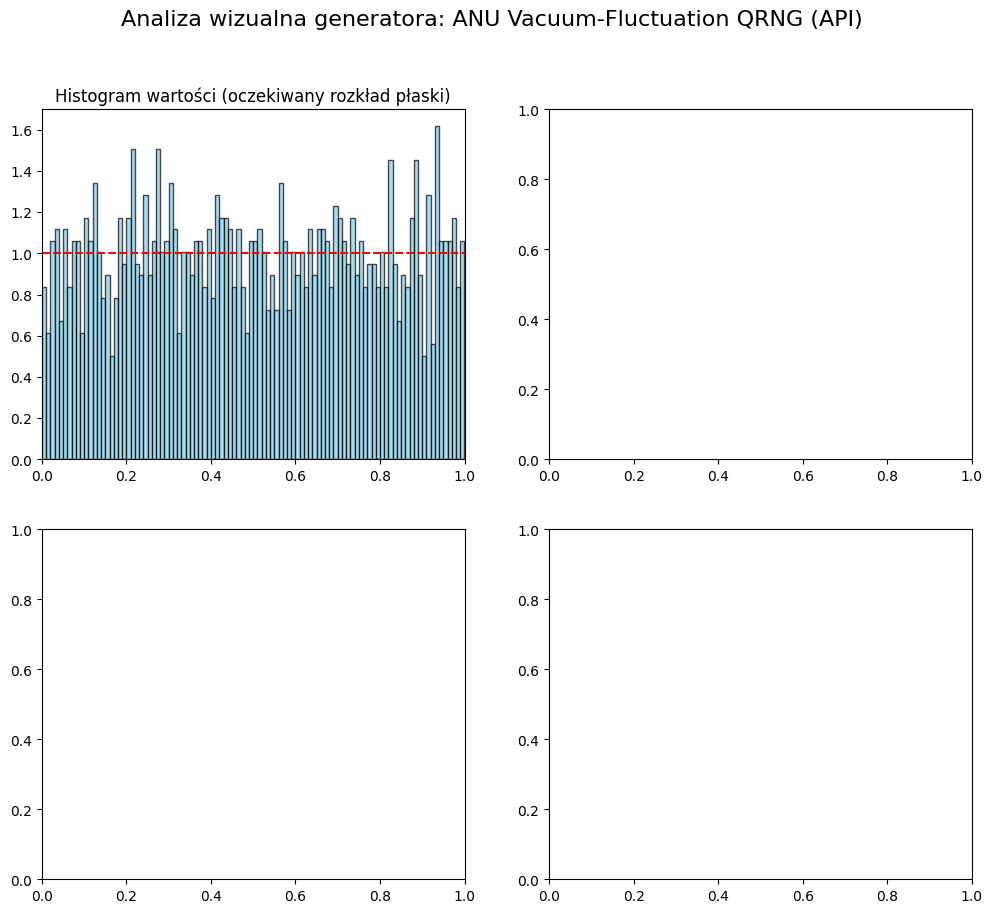

In [2]:
generator = ANUVacuumQRNG(
    api_url="https://api.quantumnumbers.anu.edu.au/",
    api_key="rdz5IvlD9Iask1prJGPnE8rH8PCtSNhP58u9ntmm",
    max_chunk=1024,
    timeout_sec=20.0,
    record_downloads=True,
)

results = validate_generator(generator, cfg)
print(json.dumps(results, indent=2))

# Dla API sieciowego zmniejszamy liczbe probek, aby ograniczyc liczbe zapytan HTTP.
run_visual_tests(generator, n_samples=1_792)

# --- Dump run artifacts for offline reuse ---
run_id = datetime.now().strftime("%Y%m%d-%H%M%S")
run_dir = Path("noteboooks") / "P7-runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)

(results_path := run_dir / "validation_results.json").write_text(
    json.dumps(results, indent=2),
    encoding="utf-8",
)

raw_path = generator.dump_download_log(str(run_dir / "api_download_uint8.bin"))
stats = generator.download_stats()

(run_dir / "run_metadata.json").write_text(
    json.dumps(
        {
            "run_id": run_id,
            "api_url": generator.api_url,
            "validation_config": {
                "n_numbers": cfg.n_numbers,
                "n_bits": cfg.n_bits,
                "approx_entropy_block_size": cfg.approx_entropy_block_size,
            },
            "visual_test_samples": 1792,
            "download_stats": stats,
            "files": {
                "validation_results": str(results_path),
                "api_download_uint8": raw_path,
            },
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Run dump saved to: {run_dir}")
print(json.dumps(stats, indent=2))

